# Important Extra Features

The goal of this notebook is to find which individual features are most common and based on our limited domain knowledge could have a significant effect on the price of cars. The goal of this is to see if we can further improve the predictions we have made in case of the `harshly_cleaned` dataset.

We are interested in the features listed in the following columns: `comfort_and_convenience`, `entertainment_and_media`, `safety_and_security`, `extras`.
These are combined text representations of specific features delimited by `;`.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_parquet("../all_car_details_harshly_cleaned.parquet")

In [4]:
df.head()

,url,make,car_title,price,seller,location,num_images,body_type,used_type,drivetrain,...,co2_emissions,comfort_and_convenience,entertainment_and_media,safety_and_security,extras,exterior_colour,paint,upholstery_colour,upholstery,age_months
0,https://www.autoscout24.com/offers/9ff-others-...,9ff,9ff,46900.0,Private seller,DE,17.0,Other,Used,Front,...,NaN,Air conditioning;Armrest;Cruise control,None,Central door lock;Driver-side airbag;Passenger...,None,White,Others,None,None,149.0
1,https://www.autoscout24.com/offers/9ff-others-...,9ff,9ff,7000.0,Private seller,IT,8.0,Sedan,Used,None,...,0.0,Auxiliary heating;Keyless central door lock;Le...,Android Auto;Bluetooth;Digital cockpit;Hands-f...,Central door lock;Central door lock with remot...,All season tyres;Alloy wheels;Touch screen,White,None,Black,Full leather,17.0
15,https://www.autoscout24.com/offers/ac-cobra-co...,ac,AC Cobra,60000.0,Private seller,IT,8.0,Convertible,Used,Front,...,NaN,Wind deflector,None,None,Spare tyre,None,None,Grey,Other,235.0
30,https://www.autoscout24.com/offers/ac-cobra-ga...,ac,AC Cobra,39900.0,Dealer,AT,17.0,Convertible,Used,Rear,...,NaN,None,Radio,None,Sport package;Sport suspension;Tuned car,Green,None,Beige,Part leather,283.0
52,https://www.autoscout24.com/offers/acm-biagini...,acm,ACM Biagini Passo,3500.0,Private seller,ES,10.0,Other,Used,None,...,NaN,None,None,None,None,Blue,Others,None,None,379.0


Let's first destructure these values and get the value counts of each possible feature.

## Extras

In [6]:
extras_counts = df['extras'].str.split(';').explode().value_counts()
print(extras_counts)

extras
Alloy wheels                             147570
Automatically dimming interior mirror    104826
Touch screen                              85610
Voice Control                             77709
Roof rack                                 72204
                                          ...  
Municipal vehicle                             5
Crane                                         3
Alloy wheels (25")                            1
Alloy wheels (11")                            1
Cable winch                                   1
Name: count, Length: 62, dtype: int64


We can see that there are 62 unique values, let's plot them in a way where we only plot values that is present for more than 5% of cars.

In [49]:
extras_counts_gt_5 = extras_counts[extras_counts > 0.05 * len(df)]
len(extras_counts_gt_5)

26

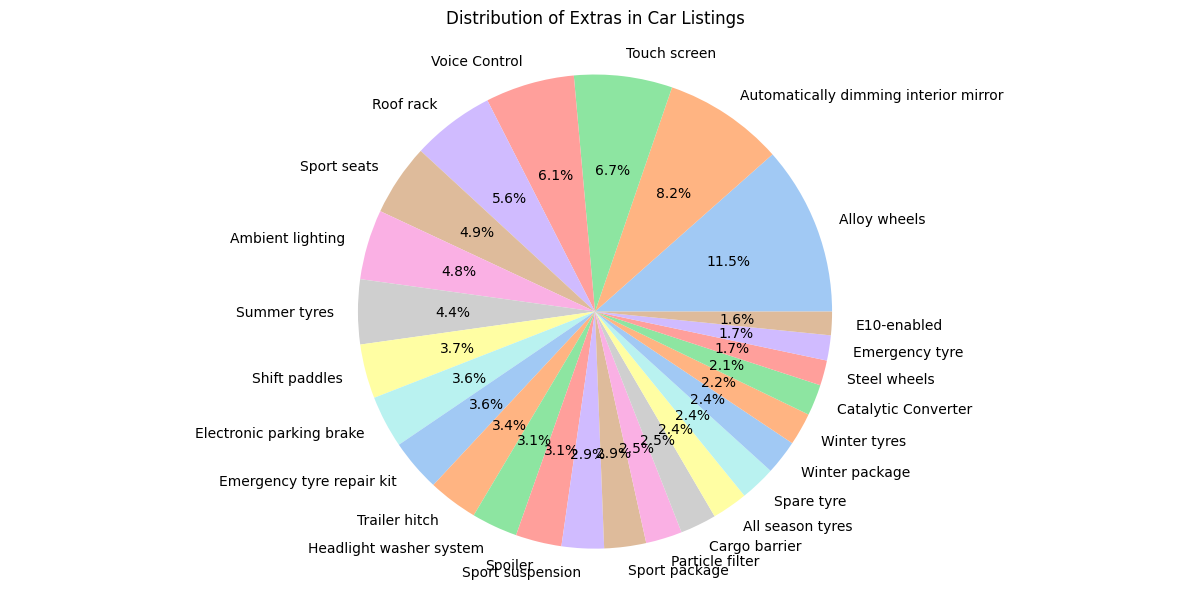

In [52]:
colors = sns.color_palette('pastel')

plt.figure(figsize=(12, 6))
plt.pie(
    extras_counts_gt_5,
    labels=extras_counts_gt_5.index,
    autopct='%1.1f%%',
    startangle=0,         # Start the pie at 0 degrees
    colors=colors
)
plt.title('Distribution of Extras in Car Listings', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

These seem fine to add, only 26 new OHE values is not too bad either.

Now let's do the same for our other columns.

## Comfort and Convenience

In [54]:
cc_counts = df['comfort_and_convenience'].str.split(';').explode().value_counts()
print(cc_counts)
print(len(cc_counts))

comfort_and_convenience
Power windows                          246647
Electrical side mirrors                223447
Multi-function steering wheel          180648
Park Distance Control                  179697
Air conditioning                       179243
Cruise control                         176332
Leather steering wheel                 173234
Armrest                                163862
Parking assist system sensors rear     160699
Rain sensor                            159200
Light sensor                           146678
Navigation system                      138964
Seat heating                           129997
Tinted windows                         129249
Hill Holder                            121097
Automatic climate control              118956
Start-stop system                      114547
Parking assist system camera           107732
Parking assist system sensors front    102987
Split rear seats                        93333
Keyless central door lock               85356
Lumbar sup

We see that there are lee unique values here, but let's check again only the ones that are available for more than 5% of all cars.

In [59]:
cc_counts_gt_5 = cc_counts[cc_counts > 0.05 * len(df)]
len(cc_counts_gt_5)

35

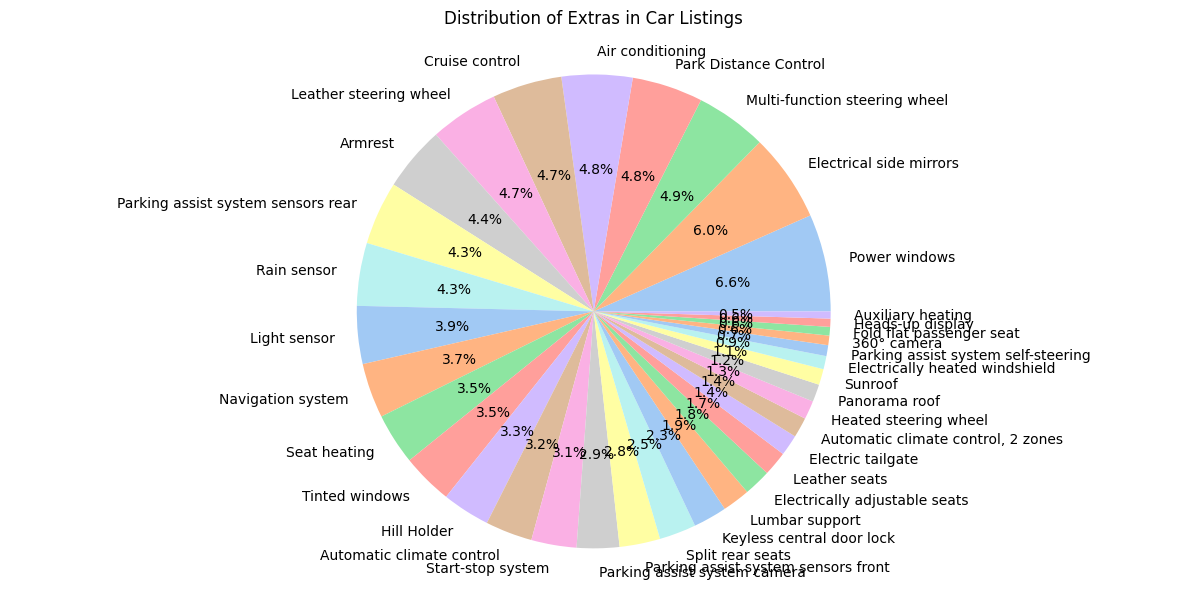

In [60]:
plt.figure(figsize=(12, 6))
plt.pie(
    cc_counts_gt_5,
    labels=cc_counts_gt_5.index,
    autopct='%1.1f%%',
    startangle=0,         # Start the pie at 0 degrees
    colors=colors
)
plt.title('Distribution of Extras in Car Listings', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

We can see that this gives us 35 unique values, which is a lot, but many of the more usefull features are actually to the lower-end of this feature, e.g. the 360 camera.

It is also noteworthy that there is no consensus on th naming of a pretty important feature, we can see both `Sunroof` / `Panorama roof` naming of the same feature. We will have to handle this by merging when using these features for prediction.

We can also remove a few columns that do not give much information in the modern world, such as: `power_windows`, `electrical_side_mirror`, `armrest`, `rain_sensor`.

## Entertainment and Media

In [61]:
em_counts = df['entertainment_and_media'].str.split(';').explode().value_counts()
print(em_counts)
print(len(em_counts))

entertainment_and_media
Radio                                 205197
On-board computer                     182880
Bluetooth                             179887
Hands-free equipment                  133468
USB                                   130444
MP3                                    99751
CD player                              97957
Digital radio                          95055
Sound system                           85882
Apple CarPlay                          78824
Android Auto                           74537
Digital cockpit                        56366
Induction charging for smartphones     34013
Integrated music streaming             29349
WLAN / WiFi hotspot                    21638
Television                              3600
Name: count, dtype: int64
16


In [65]:
em_counts_gt_5 = em_counts[em_counts > 0.05 * len(df)]
len(em_counts_gt_5)

15

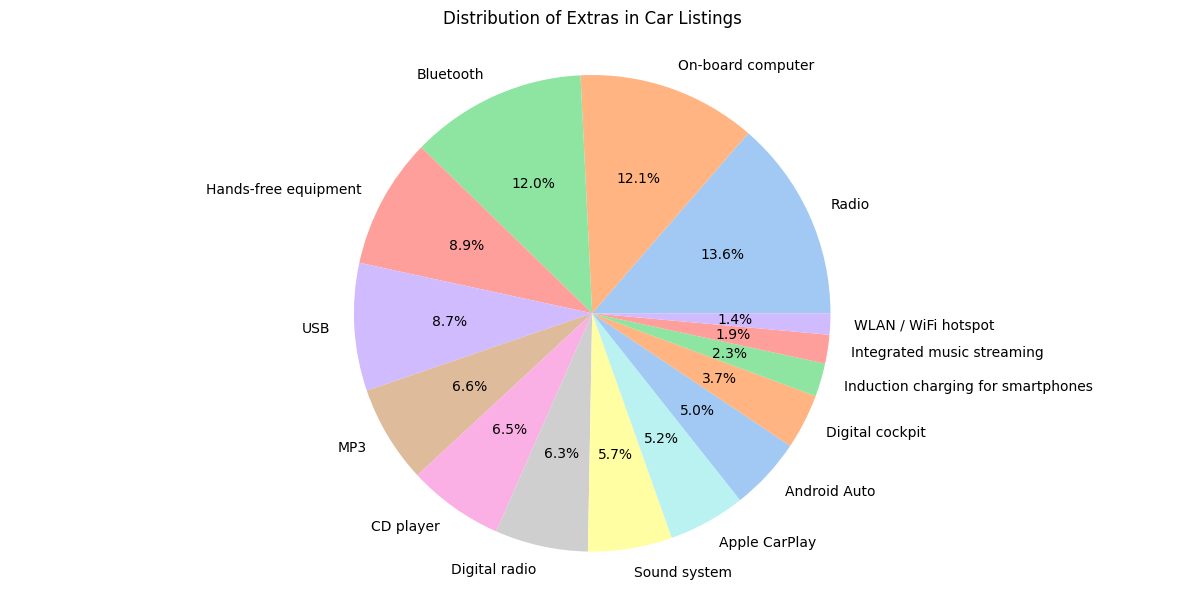

In [67]:
plt.figure(figsize=(12, 6))
plt.pie(
    em_counts_gt_5,
    labels=em_counts_gt_5.index,
    autopct='%1.1f%%',
    startangle=0,         # Start the pie at 0 degrees
    colors=colors
)
plt.title('Distribution of Extras in Car Listings', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

Here we should probably get rid of `Radio` as it is a too common feature, it is most likely there for the cars that did not list it too.

## Safety and Security

In [68]:
ss_counts = df['safety_and_security'].str.split(';').explode().value_counts()
print(ss_counts)
print(len(ss_counts))

safety_and_security
ABS                                      250921
Driver-side airbag                       250795
Passenger-side airbag                    237235
Power steering                           228914
Side airbag                              221150
Electronic stability control             208967
Central door lock                        201854
Immobilizer                              189499
Isofix                                   177848
Fog lights                               168955
Traction control                         157779
Tire pressure monitoring system          150294
Central door lock with remote control    138261
Head airbag                              127950
Daytime running lights                   118234
Alarm system                             105237
Emergency brake assistant                105004
LED Daytime Running Lights                99867
LED Headlights                            90913
Lane departure warning system             84016
Rear airbag         

In [69]:
ss_counts_gt_5 = ss_counts[ss_counts > 0.05 * len(df)]
len(ss_counts_gt_5)

34

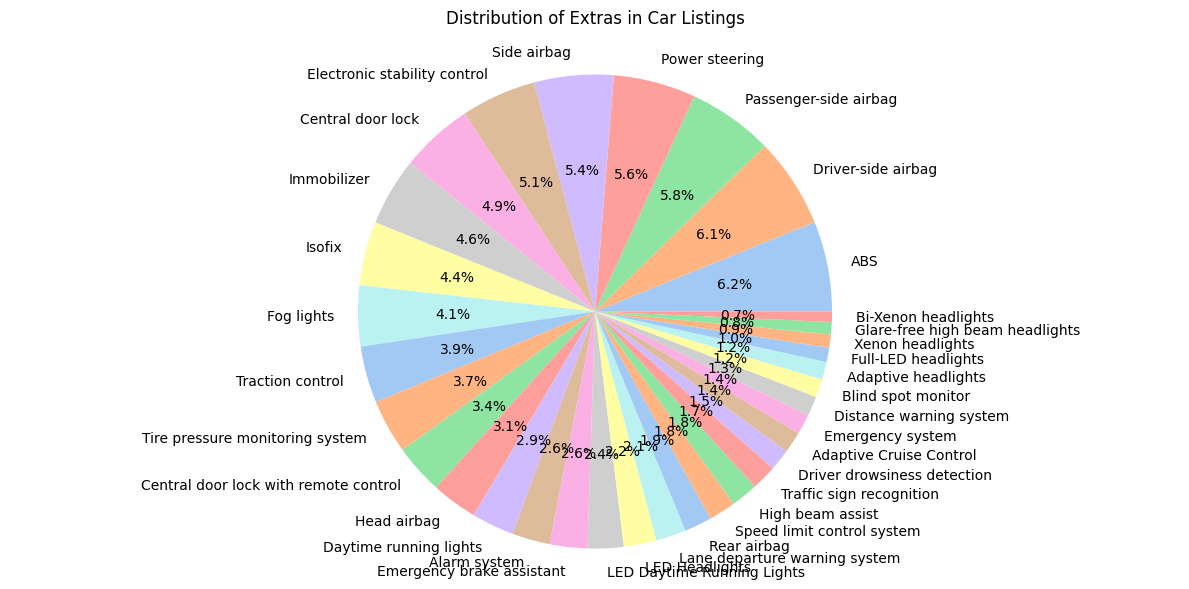

In [71]:
plt.figure(figsize=(12, 6))
plt.pie(
    ss_counts_gt_5,
    labels=ss_counts_gt_5.index,
    autopct='%1.1f%%',
    startangle=0,         # Start the pie at 0 degrees
    colors=colors
)
plt.title('Distribution of Extras in Car Listings', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

Here the following features could be omitted as they are very popular and probably a very large portion of our cars have it, even those that do not list it:

```plaintext
- ABS                                      (250921)
- Driver-side airbag                       (250795)
- Passenger-side airbag                    (237235)
- Power steering                           (228914)
- Side airbag                              (221150)
- Electronic stability control             (208967)
- Central door lock                        (201854)
- Immobilizer                              (189499)
- Isofix                                   (177848)
```